In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.append('..')
from src.features.blocking import (
    make_block_keys,
    block_size_stats,
    calculate_reduction_ratio,
    generate_candidate_pairs_from_block,
    evaluate_blocking_recall,
)

In [2]:
# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_parquet("../data/processed/processed_dataset.parquet")
test_pairs = pd.read_parquet("../data/processed/test_pairs.parquet")

print(f"Dataset rows: {len(df):,}")
print(f"Test pairs: {len(test_pairs):,}")

Dataset rows: 3,655,635
Test pairs: 14,812


In [3]:
# ============================================================
# OPTIONAL SAMPLE FOR BLOCKING RESEARCH
# ============================================================

# Для первичного исследования берем sample, чтобы быстро проверять стратегии.
# Потом применим выбранную стратегию ко всему датасету.

df_sample = df.sample(
    200_000,
    random_state=42,
)

print(f"Sample rows: {len(df_sample):,}")

Sample rows: 200,000


In [4]:
# ============================================================
# CREATE BLOCK KEYS
# ============================================================

df_sample = make_block_keys(
    df_sample,
    name_col="name_latin",
)

display(
    df_sample[
        [
            "party_name",
            "name_latin",
            "block_prefix_4",
            "block_first_token_4",
            "block_prefix_len",
            "block_first_token_len",
            "block_sorted_tokens",
        ]
    ].head()
)

,party_name,name_latin,block_prefix_4,block_first_token_4,block_prefix_len,block_first_token_len,block_sorted_tokens
1542894,САНИЯЗОВ СЕРИК САНСЫЗБАЕВИЧ,saniyazov serik sansyzbaevich,sani,sani,sani_5,sani_5,saniyazov sansyzbaevich serik
2648308,Баточир Батзаяа,batochir batzayaa,bato,bato,bato_3,bato_3,batochir batzayaa
377768,ԱՐԴՅՈՒՆԱԲԵՐԱԿԱՆ ԸՆԿԵՐՈՒԹՅՈՒՆ ԲԸ,ardyounaberakan ynkeroutyoun by,ardy,ardy,ardy_6,ardy_6,ardyounaberakan by ynkeroutyoun
1464832,ҚОСЫБАЕВ АЗАМАТ САҒАДӘЛІҰЛЫ,kosybaev azamat sagadaliuly,kosy,kosy,kosy_5,kosy_5,azamat kosybaev sagadaliuly
2917894,ойдов сүхбуян,oi dov suhbuyan,oido,oi,oido_3,oi_3,dov oi suhbuyan


In [5]:
# ============================================================
# BLOCK SIZE ANALYSIS
# ============================================================

block_cols = [
    "block_prefix_4",
    "block_first_token_4",
    "block_prefix_len",
    "block_first_token_len",
    "block_sorted_tokens",
]

for block_col in block_cols:
    print("=" * 60)
    print(block_col)
    print("=" * 60)

    stats = block_size_stats(df_sample, block_col)

    display(stats.head(10))
    display(stats["block_size"].describe())

    reduction = calculate_reduction_ratio(df_sample, block_col)

    print(f"Total pairs: {reduction['total_pairs']:,.0f}")
    print(f"Candidate pairs: {reduction['candidate_pairs']:,.0f}")
    print(f"Reduction ratio: {reduction['reduction_ratio']:.4%}")

block_prefix_4


,block_prefix_4,block_size
667,anha,2696
7432,monh,1572
1462,baya,1561
3241,erde,1359
3747,ganb,1173
9063,pure,1059
7195,memm,1053
2422,dash,1031
37,abdu,1023
7348,mirz,1018


count    13252.000000
mean        15.092062
std         65.986021
min          1.000000
25%          1.000000
50%          2.000000
75%          7.000000
max       2696.000000
Name: block_size, dtype: float64

Total pairs: 19,999,900,000
Candidate pairs: 30,257,660
Reduction ratio: 99.8487%
block_first_token_4


,block_first_token_4,block_size
603,anha,2696
6755,monh,1571
1350,baya,1561
3008,erde,1359
3476,ganb,1173
1201,bai,1067
8294,pure,1059
6531,memm,1053
2264,dash,1031
38,abdu,1023


...

count    26517.000000
mean         7.542331
std         32.860889
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max       2695.000000
Name: block_size, dtype: float64

Total pairs: 19,999,900,000
Candidate pairs: 14,970,726
Reduction ratio: 99.9251%
block_sorted_tokens


,block_sorted_tokens,block_size
35467,anhayt kazmakerpoutyoun,2692
122742,holding limited metals neo,781
143994,mirzaaziz mousakhanov,619
108303,ershova svetlana,500
37508,ardyounaberakan by ynkeroutyoun,478
133783,kompania promishlennaya,298
67478,bazhnetomserov holding limited masnavor metals...,205
23619,aleqsandr trounov,165
110844,fayrbyrd menejment spy,155
109566,evgenia vasileva,146


count    162116.000000
mean          1.233685
std           7.571766
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max        2692.000000
Name: block_size, dtype: float64

Total pairs: 19,999,900,000
Candidate pairs: 4,670,528
Reduction ratio: 99.9766%


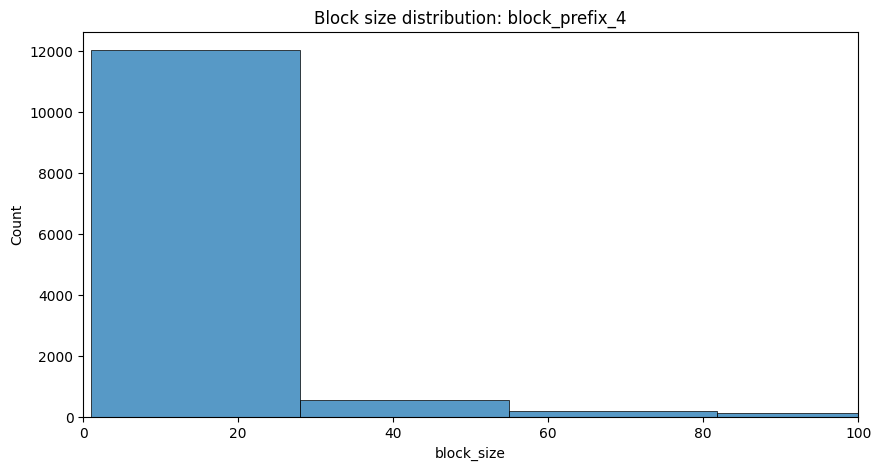

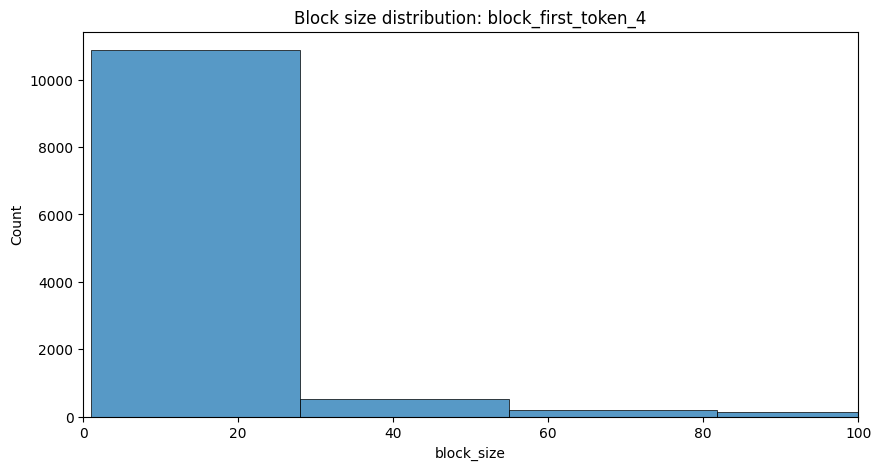

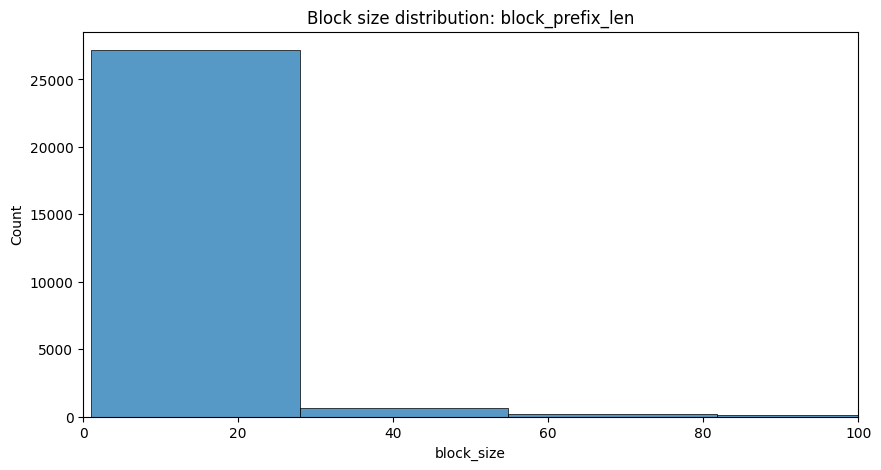

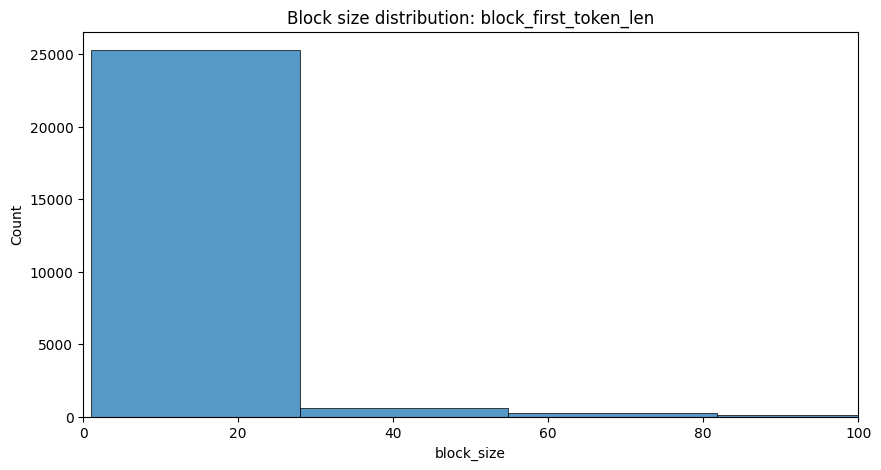

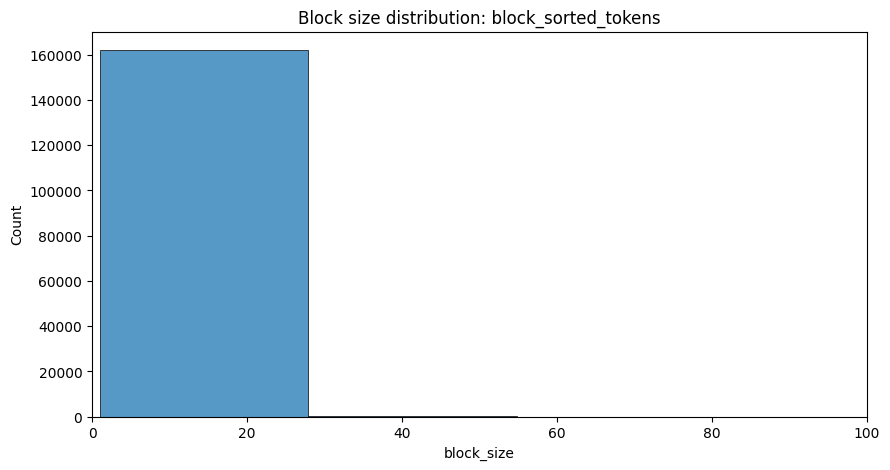

In [6]:
# ============================================================
# VISUALIZE BLOCK SIZE DISTRIBUTIONS
# ============================================================

for block_col in block_cols:
    stats = block_size_stats(df_sample, block_col)

    plt.figure(figsize=(10, 5))

    sns.histplot(
        stats["block_size"],
        bins=100,
    )

    plt.xlim(0, 100)
    plt.title(f"Block size distribution: {block_col}")
    plt.show()

In [7]:
# ============================================================
# APPLY BLOCKING TO TEST PAIRS DATASET RECORDS
# ============================================================

# Для оценки recall blocking берем только записи, которые есть в test_pairs.
# Это быстро и позволяет понять, покрывает ли blocking известные positive pairs.

test_indices = set(test_pairs["idx1"]) | set(test_pairs["idx2"])

df_test_records = df.loc[list(test_indices)].copy()

df_test_records = make_block_keys(
    df_test_records,
    name_col="name_latin",
)

print(f"Unique records in test pairs: {len(df_test_records):,}")

Unique records in test pairs: 21,811


In [8]:
# ============================================================
# EVALUATE BLOCKING RECALL ON TEST PAIRS
# ============================================================

blocking_results = []

for block_col in block_cols:
    candidates = generate_candidate_pairs_from_block(
        df_test_records,
        block_col=block_col,
        max_block_size=500,
    )

    recall_result = evaluate_blocking_recall(
        labeled_pairs=test_pairs,
        candidate_pairs=candidates,
    )

    reduction_result = calculate_reduction_ratio(
        df_test_records,
        block_col,
    )

    blocking_results.append(
        {
            "block_col": block_col,
            "candidate_pairs": len(candidates),
            "positive_pairs": recall_result["positive_pairs"],
            "covered_positive_pairs": recall_result["covered_positive_pairs"],
            "blocking_recall": recall_result["blocking_recall"],
            "reduction_ratio": reduction_result["reduction_ratio"],
        }
    )

blocking_results_df = pd.DataFrame(blocking_results)

display(
    blocking_results_df
    .sort_values("blocking_recall", ascending=False)
)

,block_col,candidate_pairs,positive_pairs,covered_positive_pairs,blocking_recall,reduction_ratio
2,block_prefix_len,430237,7305,7287,0.997536,0.996049
4,block_sorted_tokens,83528,7305,7287,0.997536,0.997507
3,block_first_token_len,427329,7305,7287,0.997536,0.996062
0,block_prefix_4,944754,7305,7122,0.974949,0.993005
1,block_first_token_4,931169,7305,7122,0.974949,0.993062


In [9]:
# ============================================================
# MULTI-PASS BLOCKING
# ============================================================

candidate_frames = []

selected_block_cols = [
    "block_prefix_4",
    "block_first_token_4",
    "block_prefix_len",
    "block_first_token_len",
    "block_sorted_tokens",
]

for block_col in selected_block_cols:
    candidates = generate_candidate_pairs_from_block(
        df_test_records,
        block_col=block_col,
        max_block_size=500,
    )

    candidate_frames.append(candidates)

multi_candidates = pd.concat(
    candidate_frames,
    ignore_index=True,
)

multi_candidates["left"] = multi_candidates[["idx1", "idx2"]].min(axis=1)
multi_candidates["right"] = multi_candidates[["idx1", "idx2"]].max(axis=1)

multi_candidates["pair_key"] = (
    multi_candidates["left"].astype(str)
    + "_"
    + multi_candidates["right"].astype(str)
)

multi_candidates = (
    multi_candidates
    .drop_duplicates("pair_key")
    .reset_index(drop=True)
)

multi_recall = evaluate_blocking_recall(
    labeled_pairs=test_pairs,
    candidate_pairs=multi_candidates,
)

print("=" * 60)
print("MULTI-PASS BLOCKING RESULT")
print("=" * 60)

print(f"Candidate pairs: {len(multi_candidates):,}")
print(f"Positive pairs: {multi_recall['positive_pairs']:,}")
print(f"Covered positives: {multi_recall['covered_positive_pairs']:,}")
print(f"Blocking recall: {multi_recall['blocking_recall']:.4%}")

MULTI-PASS BLOCKING RESULT
Candidate pairs: 1,019,750
Positive pairs: 7,305
Covered positives: 7,305
Blocking recall: 100.0000%


In [10]:
# ============================================================
# SAVE BLOCKING RESULTS
# ============================================================

blocking_results_df.to_parquet(
    "../data/processed/blocking_results.parquet",
    index=False,
)

multi_candidates.to_parquet(
    "../data/processed/test_blocking_candidates.parquet",
    index=False,
)

print("Saved:")
print("../data/processed/blocking_results.parquet")
print("../data/processed/test_blocking_candidates.parquet")

Saved:
../data/processed/blocking_results.parquet
../data/processed/test_blocking_candidates.parquet
